# Phase 0 — Donor Structure Audit of cpg0038

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PatrickJReed/cerberus-neuro/blob/main/notebooks/03_donor_audit.ipynb)

**Goal:** Tabulate donor lines per condition, per cell type. Compute imbalance metrics.
Estimate the crop budget for Phase 2. Produce inputs for the Phase 0 audit report.

**Spec:** `docs/superpowers/specs/2026-05-12-argus-cells-design.md`, §3 + §5.
**Plan:** `docs/superpowers/plans/2026-05-12-argus-cells-phase-0-donor-audit.md`.

In [1]:
# Install the argus_cells package code only (--no-deps) so pip never touches
# Colab's pre-built numpy / scipy / scikit-learn. Upgrading those mid-session
# breaks the numpy<->scipy ABI (the "_blas_supports_fpe" / "_center" ImportErrors).
!pip install -q --upgrade --no-deps git+https://github.com/PatrickJReed/argus-cells.git@main
# Only the pure-Python deps Colab may lack; these pull NO numpy-linked packages.
!pip install -q boto3 huggingface_hub

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from argus_cells.data import build_manifest
from argus_cells.audit import (
    donor_counts_by_condition,
    donor_well_table,
    imbalance_metric,
    crop_budget_estimate,
)

pd.set_option("display.max_rows", 200)

CACHE_DIR = Path("/content/drive/MyDrive/cerberus-neuro/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Cell 5 — Build the manifest from cpg0038 platemaps + load_data CSVs.
# This is identical to what 01_data_exploration.ipynb does; ~1-3 min.
manifest = build_manifest(cache_dir=CACHE_DIR)
print(f"Manifest rows (sites): {len(manifest):,}")
print(f"Unique wells: {manifest.groupby(['Metadata_Plate', 'Metadata_Well']).ngroups:,}")
print(f"Cell types: {sorted(manifest['Metadata_cell_type'].unique())}")
print(f"Conditions: {sorted(manifest['Metadata_line_condition'].unique())}")
print(f"Donors (line_IDs): {sorted(manifest['Metadata_line_ID'].unique())}")
manifest.head()

Manifest rows (sites): 10,532
Unique wells: 1,724
Cell types: ['astro', 'neuron', 'progen', 'stem']
Conditions: ['control', 'deletion']
Donors (line_IDs): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48)]


,URL_OrigDNA,URL_OrigBrightfield,URL_OrigMito,URL_OrigAGP,URL_OrigER,URL_OrigRNA,Metadata_Plate,Metadata_Well,Metadata_Site,batch,Metadata_cell_type,Metadata_line_ID,Metadata_line_condition,Metadata_line_source
0,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,PE_PP_Plate2,A01,1,NCP_ASTROCYTES_1,astro,1,control,human
1,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,PE_PP_Plate2,A01,2,NCP_ASTROCYTES_1,astro,1,control,human
2,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,PE_PP_Plate2,A01,3,NCP_ASTROCYTES_1,astro,1,control,human
3,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,PE_PP_Plate2,A01,4,NCP_ASTROCYTES_1,astro,1,control,human
4,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,s3://cellpainting-gallery/cpg0038-tegtmeyer-ne...,PE_PP_Plate2,A01,5,NCP_ASTROCYTES_1,astro,1,control,human


In [5]:
# Cell 6 — Donor counts per condition. Gate check: N >= 3 per condition.
counts = donor_counts_by_condition(manifest)
print("Donor counts per condition:")
for cond, n in counts.items():
    flag = "OK" if n >= 3 else "BLOCKER"
    print(f"  {cond}: {n} donor lines  [{flag}]")

Donor counts per condition:
  control: 24 donor lines  [OK]
  deletion: 24 donor lines  [OK]


In [6]:
# Cell 7 — Full per-(cell_type, condition, donor) well-count table.
well_table = donor_well_table(manifest)
print(f"Total (cell_type, condition, donor) groups: {len(well_table)}")
print(well_table.to_string(index=False))

Total (cell_type, condition, donor) groups: 192
cell_type line_condition  line_ID  n_wells
    astro        control        1        4
    astro        control        2        4
    astro        control        3        4
    astro        control        4        4
    astro        control        5        4
    astro        control        6        4
    astro        control        7        4
    astro        control        8        1
    astro        control        9        4
    astro        control       10        4
    astro        control       11        4
    astro        control       12        4
    astro        control       13        4
    astro        control       14        4
    astro        control       15        4
    astro        control       16        4
    astro        control       17        4
    astro        control       18        4
    astro        control       19        4
    astro        control       20        3
    astro        control       21        4
    as

In [7]:
# Cell 8 — Per-(cell_type, condition) donor-balance CV.
# CV = 0 is perfectly balanced; high CV means one donor dominates.
imbalance = imbalance_metric(well_table)
imb_df = pd.DataFrame(
    [
        {"cell_type": k[0], "line_condition": k[1], "cv": v["cv"], "n_donors": v["n_donors"]}
        for k, v in imbalance.items()
    ]
)
print(imb_df.to_string(index=False))

cell_type line_condition       cv  n_donors
    astro        control 0.162681        24
    astro       deletion 0.000000        24
   neuron        control 0.000000        24
   neuron       deletion 0.000000        24
   progen        control 0.000000        24
   progen       deletion 0.000000        24
     stem        control 0.000000        24
     stem       deletion 0.000000        24


In [8]:
# Cell 9 — Crop budget upper-bound at three candidate crops_per_site values.
# Phase 0.5 / Phase 1 yielded ~16k crops at crops_per_site=10. Phase 2 target
# is ~50-100k. Try crops_per_site = 10, 30, 50.
for cps in [10, 30, 50]:
    budget = crop_budget_estimate(manifest, crops_per_site=cps)
    print(
        f"  crops_per_site={cps:>3}: "
        f"sites={budget['n_sites']:,}, "
        f"wells={budget['n_wells']:,}, "
        f"upper-bound crops={budget['max_crops_upper_bound']:,}"
    )

  crops_per_site= 10: sites=10,532, wells=1,724, upper-bound crops=105,320
  crops_per_site= 30: sites=10,532, wells=1,724, upper-bound crops=315,960
  crops_per_site= 50: sites=10,532, wells=1,724, upper-bound crops=526,600


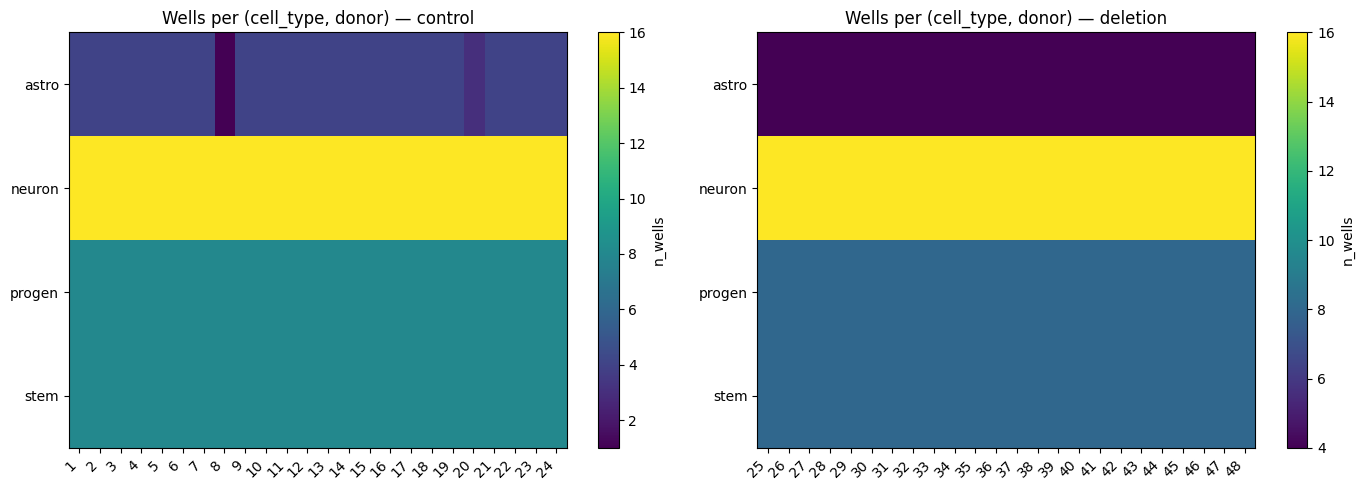

In [9]:
# Cell 10 — Heatmap of wells per (cell_type, donor), faceted by condition.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, condition in zip(axes, ["control", "deletion"]):
    sub = well_table[well_table["line_condition"] == condition]
    pivot = sub.pivot_table(
        index="cell_type",
        columns="line_ID",
        values="n_wells",
        fill_value=0,
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"Wells per (cell_type, donor) — {condition}")
    fig.colorbar(im, ax=ax, label="n_wells")
plt.tight_layout()
plt.show()

In [10]:
# Cell 11 — Summary block for the audit report. Paste this into the
# `Quantitative findings` section of docs/superpowers/results/2026-05-12-phase-0-donor-audit.md
print("=" * 60)
print("PHASE 0 AUDIT SUMMARY")
print("=" * 60)
print()
print("Donor counts per condition:")
for cond, n in counts.items():
    flag = "OK" if n >= 3 else "BLOCKER"
    print(f"  {cond}: {n} donor lines  [{flag}]")
print()
print("Per-(cell_type, condition) imbalance (donor-balance CV):")
for (ct, cond), val in imbalance.items():
    print(f"  ({ct:>6}, {cond:>8}): CV={val['cv']:.3f}, N_donors={val['n_donors']}")
print()
print("Crop budget at crops_per_site=30:")
budget = crop_budget_estimate(manifest, crops_per_site=30)
print(f"  upper-bound crops: {budget['max_crops_upper_bound']:,}")
print(f"  realistic (60% yield): {int(budget['max_crops_upper_bound'] * 0.60):,}")
print(f"  realistic (90% yield): {int(budget['max_crops_upper_bound'] * 0.90):,}")

PHASE 0 AUDIT SUMMARY

Donor counts per condition:
  control: 24 donor lines  [OK]
  deletion: 24 donor lines  [OK]

Per-(cell_type, condition) imbalance (donor-balance CV):
  ( astro,  control): CV=0.163, N_donors=24
  ( astro, deletion): CV=0.000, N_donors=24
  (neuron,  control): CV=0.000, N_donors=24
  (neuron, deletion): CV=0.000, N_donors=24
  (progen,  control): CV=0.000, N_donors=24
  (progen, deletion): CV=0.000, N_donors=24
  (  stem,  control): CV=0.000, N_donors=24
  (  stem, deletion): CV=0.000, N_donors=24

Crop budget at crops_per_site=30:
  upper-bound crops: 315,960
  realistic (60% yield): 189,576
  realistic (90% yield): 284,364
